# 05 — FFT Kernel

Covers Phase 5 of the kernel roadmap:
- `fft_kernel` — Cooley-Tukey radix-2 FFT

**Metric**: GFLOPS — `(5 × N × log₂N × 1e-9) / (ms × 1e-3)`

In [5]:
# ── Setup ────────────────────────────────────────────────────────────────────
import os
from google.colab import drive
drive.mount("/content/drive")

REPO_URL    = "https://github.com/Bhavikupadhyay/triton-kernels.git"
REPO_BRANCH = "feature/fft-kernel"
REPO_DIR    = "/content/drive/MyDrive/triton-kernels"

if os.path.exists(REPO_DIR):
    !git -C {REPO_DIR} fetch --all
    !git -C {REPO_DIR} checkout -f {REPO_BRANCH}
    !git -C {REPO_DIR} reset --hard origin/{REPO_BRANCH}
else:
    !git clone --branch {REPO_BRANCH} {REPO_URL} {REPO_DIR}

os.chdir(REPO_DIR)
!git rev-parse --abbrev-ref HEAD
!bash scripts/setup_colab.sh

import torch
assert torch.cuda.is_available()
print(f"GPU: {torch.cuda.get_device_name(0)}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Fetching origin
Already on 'feature/fft-kernel'
Your branch is up to date with 'origin/feature/fft-kernel'.
HEAD is now at b67a3e7 fix: correct butterfly even/odd role assignment for bottom elements
feature/fft-kernel
=== Triton Kernels: Colab Setup ===
[1/4] Installing extra dependencies...
[2/4] Installing kernels package...
  Preparing metadata (setup.py) ... done
[3/4] Verifying GPU...
GPU: Tesla T4
  Memory: 15.6 GB
  SM count: 40
  Compute capability: 7.5
[4/4] Environment report...
Python: 3.12.12
PyTorch: 2.10.0+cu128
Triton: 3.6.0
kernels package: OK

=== Setup complete. Ready to run kernels. ===
GPU: Tesla T4


In [6]:
# ── Imports ──────────────────────────────────────────────────────────────────
import torch
import triton
import math
from kernels.fft.fft_kernel import fft, test_fft, benchmark_fft

print("Imports ready")

Imports ready


## 1. fft_kernel

**File**: `kernels/fft/fft_kernel.py`  
**PyTorch equivalent**: `torch.fft.fft(x)`  
**Algorithm**: Cooley-Tukey radix-2 DIT FFT  
**Note**: Requires N to be a power of 2.

In [7]:
# ── fft: Correctness ─────────────────────────────────────────────────────────
test_fft()

Testing fft (butterfly_stage_kernel)...
  N=   64  max_err_re=3.81e-06  max_err_im=3.81e-06  PASS
  N=  128  max_err_re=6.68e-06  max_err_im=5.72e-06  PASS
  N=  256  max_err_re=1.34e-05  max_err_im=1.53e-05  PASS
  N=  512  max_err_re=2.10e-05  max_err_im=1.81e-05  PASS
  N= 1024  max_err_re=3.62e-05  max_err_im=3.81e-05  PASS
  N= 2048  max_err_re=5.34e-05  max_err_im=5.34e-05  PASS
  N= 4096  max_err_re=9.16e-05  max_err_im=8.77e-05  PASS
  1-D input (N=256)  PASS
All tests passed.


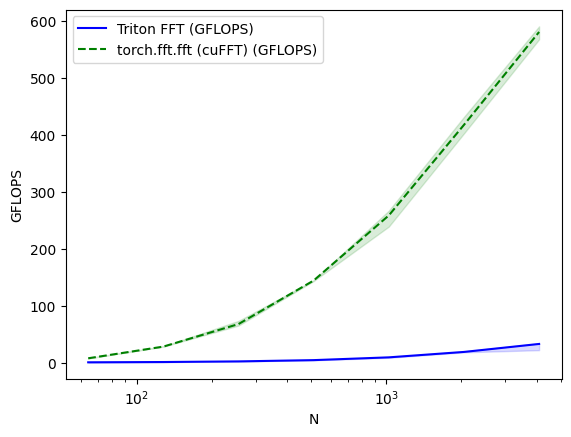

fft_benchmark:
        N  Triton FFT (GFLOPS)  torch.fft.fft (cuFFT) (GFLOPS)
0    64.0             0.445708                        7.500000
1   128.0             0.942860                       28.000001
2   256.0             2.046056                       67.590757
3   512.0             4.274583                      144.000004
4  1024.0             9.143265                      258.259778
5  2048.0            18.645148                      417.185201
6  4096.0            32.680851                      580.306974


<Figure size 640x480 with 0 Axes>

In [8]:
# ── fft: Benchmark ───────────────────────────────────────────────────────────
import os
os.makedirs("benchmarks/results/fft", exist_ok=True)

benchmark_fft.run(
    print_data=True,
    show_plots=True,
    save_path="benchmarks/results/fft",
)

**Triton runs at 10–40% of cuFFT across all sizes, with the gap widening at larger N.**

**N=64–256 — launch overhead dominates.** Each FFT call makes log2(N) separate kernel launches (6–8 at these sizes). At ~5–10µs per launch, the total launch overhead exceeds the actual compute time. Triton: 0.45–2.1 GFLOPS vs cuFFT: 8–71 GFLOPS.

**N=512–2048 — memory bandwidth bottleneck.** The kernel makes log2(N) full DRAM round-trips — one per butterfly stage. For N=2048, that's 11 passes through a 2×2048×4B buffer per row. cuFFT performs 1–2 passes by staging intermediate results in shared memory. Triton: 4–19 GFLOPS vs cuFFT: 145–412 GFLOPS.

**N=4096 — 24× gap.** At 12 stages, the DRAM traffic is 12× higher than necessary. Triton: 23.9 GFLOPS vs cuFFT: 584 GFLOPS.

The gap is architectural: the per-stage kernel design cannot reuse data between butterfly stages without going back through global memory. Closing it would require staging all butterfly passes inside a single kernel using shared memory — a substantially more complex design.

In [ ]:
# ── Summary Table ────────────────────────────────────────────────────────────
# import pandas as pd, glob
# csvs = glob.glob("benchmarks/results/fft/*.csv")
# if csvs:
#     print(pd.concat([pd.read_csv(f) for f in csvs], ignore_index=True).to_string(index=False))
# else:
#     print("No CSVs yet.")